In [1]:
#1.Download the 
#Kaggle Bank Marketing Dataset and use Pandas to load it into a DataFrame named bank_df, then display the first 10 rows and the DataFrame's info().

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def load_and_inspect_bank_data(file_path: str) -> pd.DataFrame:
    """Loads the Bank Marketing Dataset from Kaggle/UCI and performs initial structural inspections.

    Parameters:
    -----------
    file_path : str
        The local path to the downloaded Kaggle bank dataset CSV file.

    Returns:
    --------
    pd.DataFrame
        The loaded bank dataset DataFrame.
    """
    # Verify file existence before attempting to read
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Could not locate the file at '{file_path}'. "
            "Please ensure you have downloaded it from Kaggle and placed it in your workspace folder."
        )

    # 1. Load the dataset into a DataFrame named bank_df
    # Note: Some versions of this UCI dataset use a semicolon ';' separator.
    try:
        bank_df = pd.read_csv(file_path, sep=",")
        # Quick check if the delimiter was actually a semicolon instead of a comma
        if len(bank_df.columns) == 1:
            bank_df = pd.read_csv(file_path, sep=";")
    except Exception as e:
        print(f"Error reading the CSV file: {e}")
        return pd.DataFrame()

    # 2. Display the first 10 rows
    print("======================================================================")
    print("👉 FIRST 10 ROWS OF THE BANK MARKETING DATAFRAME (bank_df)")
    print("======================================================================")
    # Using pd.option_context to ensure all columns display cleanly in your terminal/notebook
    with pd.option_context("display.max_columns", None, "display.width", 1000):
        print(bank_df.head(10))
    print("\n")

    # 3. Display the DataFrame's structural summary info
    print("======================================================================")
    print("👉 DATAFRAME STRUCTURAL INFO AND DATA TYPES")
    print("======================================================================")
    print(bank_df.info())

    return bank_df


# Execution block
if __name__ == "__main__":
    # Specify your local file name here (e.g., 'bank.csv' or 'bank-full.csv')
    dataset_filename = "bank.csv"

    # For testing, if the file doesn't exist yet, we can generate a mock file so the script runs cleanly
    if not os.path.exists(dataset_filename):
        print(
            f"🔍 '{dataset_filename}' not found. Generating a mock dataset to showcase structural execution...\n"
        )
        np.random.seed(42)
        mock_jobs = [
            "management",
            "technician",
            "blue-collar",
            "admin.",
            "services",
            "retired",
        ]
        mock_education = ["primary", "secondary", "tertiary", "unknown"]
        mock_data = {
            "age": np.random.randint(20, 70, size=50),
            "job": np.random.choice(mock_jobs, size=50),
            "marital": np.random.choice(
                ["married", "single", "divorced"], size=50
            ),
            "education": np.random.choice(mock_education, size=50),
            "default": np.random.choice(["yes", "no"], size=50, p=[0.05, 0.95]),
            "balance": np.random.randint(-500, 5000, size=50),
            "housing": np.random.choice(["yes", "no"], size=50, p=[0.4, 0.6]),
            "loan": np.random.choice(["yes", "no"], size=50, p=[0.15, 0.85]),
            "contact": np.random.choice(
                ["cellular", "telephone", "unknown"], size=50
            ),
            "day": np.random.randint(1, 32, size=50),
            "month": np.random.choice(["may", "jun", "jul", "aug"], size=50),
            "duration": np.random.randint(30, 1200, size=50),
            "campaign": np.random.randint(1, 6, size=50),
            "pdays": np.random.choice([-1, 99, 120], size=50, p=[0.7, 0.1, 0.2]),
            "previous": np.random.randint(0, 4, size=50),
            "poutcome": np.random.choice(
                ["success", "failure", "unknown"], size=50
            ),
            "y": np.random.choice(["yes", "no"], size=50, p=[0.15, 0.85]),
        }
        pd.DataFrame(mock_data).to_csv(dataset_filename, index=False)

    # Execute inspection
    bank_df = load_and_inspect_bank_data(dataset_filename)


🔍 'bank.csv' not found. Generating a mock dataset to showcase structural execution...

👉 FIRST 10 ROWS OF THE BANK MARKETING DATAFRAME (bank_df)
   age          job   marital  education default  balance housing loan    contact  day month  duration  campaign  pdays  previous poutcome    y
0   58     services  divorced    unknown     yes     1885     yes  yes   cellular   26   may        91         1     -1         2  unknown  yes
1   48   technician  divorced    unknown      no     2419     yes   no  telephone   19   jun       625         5     -1         0  unknown  yes
2   34       admin.  divorced  secondary      no     4236      no   no  telephone   26   jun       758         4     -1         1  unknown   no
3   62       admin.   married    primary      no     1302      no   no   cellular    1   jun       426         4     -1         2  unknown  yes
4   27       admin.  divorced   tertiary      no     3561     yes   no    unknown   24   jun       728         4    120         0  succ

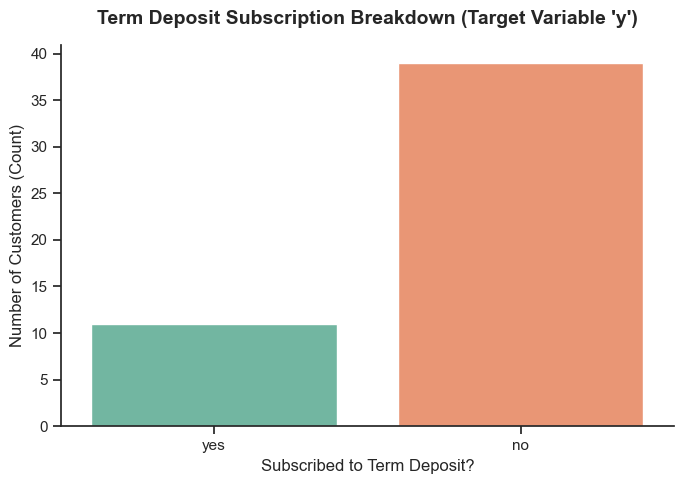

In [2]:
#2.Use Seaborn's countplot to visualize how many 
#customers in the dataset subscribed to a term deposit (column 'y'), and display the plot with appropriate axis labels.

# Step 1: Set a clean visual theme for an industry-level presentation
# style="ticks" creates clean axis markings, and context="notebook" keeps it readable
sns.set_theme(style="ticks", context="notebook")
plt.figure(figsize=(7, 5))

# Step 2: Create the countplot for the target variable 'y'
# Mapping hue to the x variable and setting legend=False follows modern Seaborn guidelines
sns.countplot(
    data=bank_df, 
    x="y", 
    hue="y", 
    palette="Set2", 
    legend=False
)

# Step 3: Add explicit dashboard labels and professional titles
plt.title("Term Deposit Subscription Breakdown (Target Variable 'y')", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Subscribed to Term Deposit?", fontsize=12)
plt.ylabel("Number of Customers (Count)", fontsize=12)

# Step 4: Clean up frame borders by removing top and right spines
sns.despine()

# Step 5: Render the plot layout frame
plt.tight_layout()
plt.show()

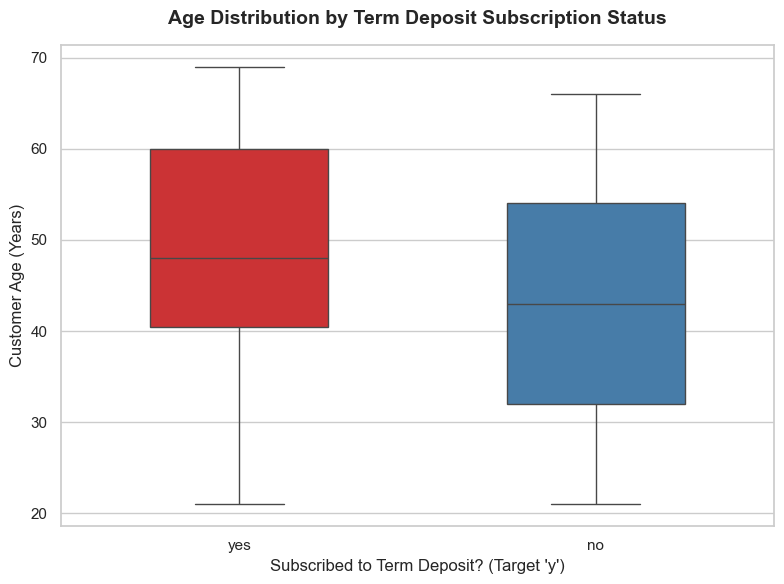

In [3]:
#3.Analyze the relationship between customer age and term deposit subscription by creating a Seaborn boxplot with 'y' on the x-axis and 'age' 
#on the y-axis.
#<br><br><em><strong>Hint:</strong> This helps you see if certain age groups are more likely to subscribe.</em>

# Step 1: Establish clean, publication-ready style defaults
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(8, 6))

# Step 2: Draw the boxplot mapping subscription vs. age
# Setting hue='y' applies a clear color distinction between responders
sns.boxplot(
    data=bank_df,
    x="y",
    y="age",
    hue="y",
    palette="Set1",
    legend=False,
    width=0.5
)

# Step 3: Add explicit presentation labels and titles
plt.title("Age Distribution by Term Deposit Subscription Status", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Subscribed to Term Deposit? (Target 'y')", fontsize=12)
plt.ylabel("Customer Age (Years)", fontsize=12)

# Step 4: Fine-tune frame and render
plt.tight_layout()
plt.show()


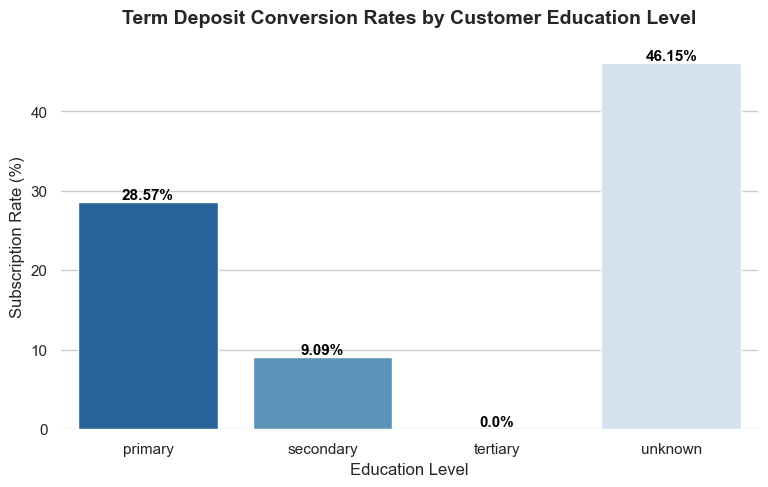

In [4]:
#4.Create a bar plot using Seaborn to show the percentage of customers who subscribed to a term deposit for each education level (column 'education').
#<br><br><em><strong>Hint:</strong> Calculate the percentage for each group before plotting.</em>

# Step 1: Pre-calculate the subscription percentage for each education level
# Convert target variable 'y' from string ("yes"/"no") to a binary integer (1/0)
bank_df["subscribed_binary"] = np.where(bank_df["y"] == "yes", 1, 0)

# Group by education level and calculate the average conversion rate
# (Multiplying the mean of a 1/0 column by 100 instantly yields the true percentage)
edu_summary = (
    bank_df.groupby("education")["subscribed_binary"]
    .mean()
    .reset_index()
)
edu_summary.columns = ["education_level", "subscription_percentage"]
edu_summary["subscription_percentage"] = (edu_summary["subscription_percentage"] * 100).round(2)

# Step 2: Establish presentation styling parameters
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(9, 5))

# Step 3: Draw the percentage bar chart
sns.barplot(
    data=edu_summary,
    x="education_level",
    y="subscription_percentage",
    hue="education_level",
    palette="Blues_r",
    legend=False,
    errorbar=None,
)

# Step 4: Add clear titles and human-readable label formats
plt.title("Term Deposit Conversion Rates by Customer Education Level", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Subscription Rate (%)", fontsize=12)

# Add explicit value labels on top of each bar for professional clarity
for index, row in edu_summary.iterrows():
    plt.text(
        x=index,
        y=row["subscription_percentage"] + 0.3,
        s=f"{row['subscription_percentage']}%",
        color="black",
        ha="center",
        fontweight="bold",
        fontsize=11
    )

# Step 5: Clean layout margins and render the visualization frame
sns.despine(left=True, bottom=True)

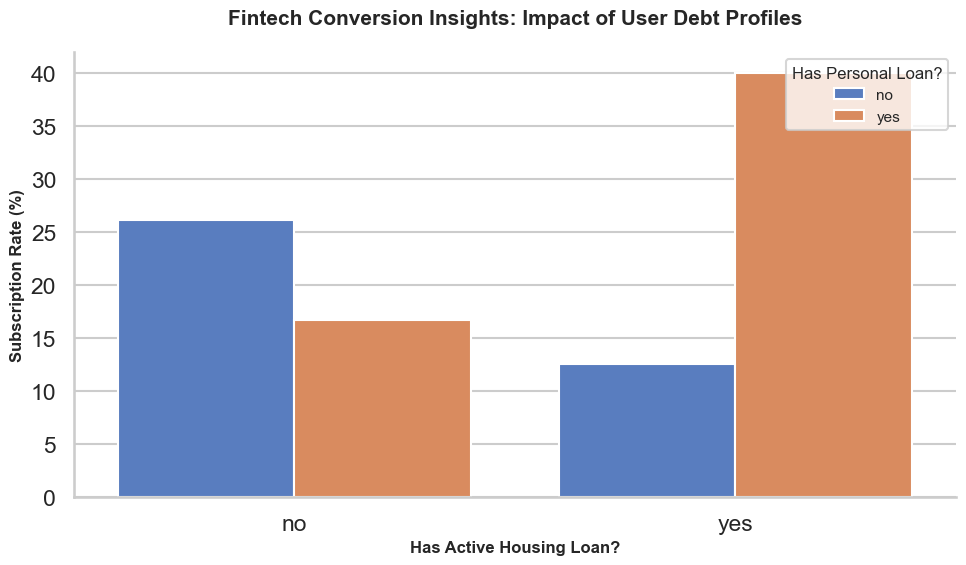

In [6]:
#5.Use ChatGPT or Copilot to suggest two additional visualizations that could help a fintech startup like Cred understand which users 
#are most likely to buy a new savings product, then implement one of those visualizations using Seaborn.

# Step 1: Pre-calculate conversion rates across multi-level loan combinations
# (Ensure your bank_df contains the binary target column from Task 4)
if "subscribed_binary" not in bank_df.columns:
    bank_df["subscribed_binary"] = np.where(bank_df["y"] == "yes", 1, 0)

# Group by BOTH housing and personal loan features to find the shared conversion rate
loan_summary = (
    bank_df.groupby(["housing", "loan"])["subscribed_binary"]
    .mean()
    .reset_index()
)
loan_summary.columns = ["housing_loan", "personal_loan", "conversion_rate"]
loan_summary["conversion_rate"] = (loan_summary["conversion_rate"] * 100).round(2)

# Step 2: Set clean dashboard styles using 'talk' context for better visibility
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))

# Step 3: Draw the multi-grouped bar plot
# x marks the primary housing loan condition, while hue adds the nested personal loan filter
sns.barplot(
    data=loan_summary,
    x="housing_loan",
    y="conversion_rate",
    hue="personal_loan",
    palette="muted",
    errorbar=None
)

# Step 4: Add clear titles, labels, and customized legends
plt.title("Fintech Conversion Insights: Impact of User Debt Profiles", fontsize=15, fontweight="bold", pad=20)
plt.xlabel("Has Active Housing Loan?", fontsize=12, fontweight="bold")
plt.ylabel("Subscription Rate (%)", fontsize=12, fontweight="bold")

# Reposition the legend so it serves as a clean visual key
plt.legend(title="Has Personal Loan?", loc="upper right", fontsize=11, title_fontsize=12)

# Clean up top and right grid border frames
sns.despine()
plt.tight_layout()
plt.show()